In [5]:
import pandas as pd

# Direct exact path from your D drive
csv_path = "D:/Data science project/Employee_Attrition_predict/Data/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(csv_path)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

Matplotlib is building the font cache; this may take a moment.
C:\Users\Hp\AppData\Local\Temp\ipykernel_18728\555271388.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df, palette='Set2')


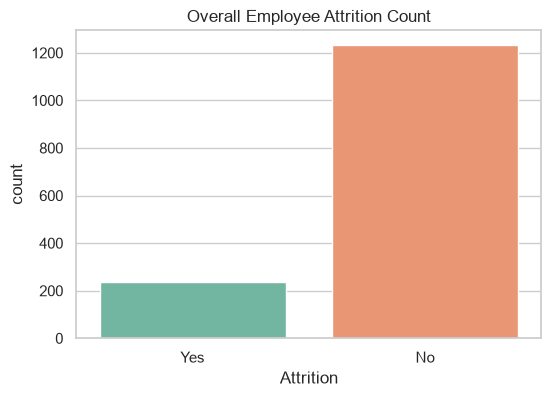

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graph neat-aa white grid template style-la vara set panrom
sns.set_theme(style="whitegrid")

# Total attrition counts check (Yes/No graph)
plt.figure(figsize=(6, 4))
sns.countplot(x='Attrition', data=df, palette='Set2')
plt.title('Overall Employee Attrition Count')
plt.show()

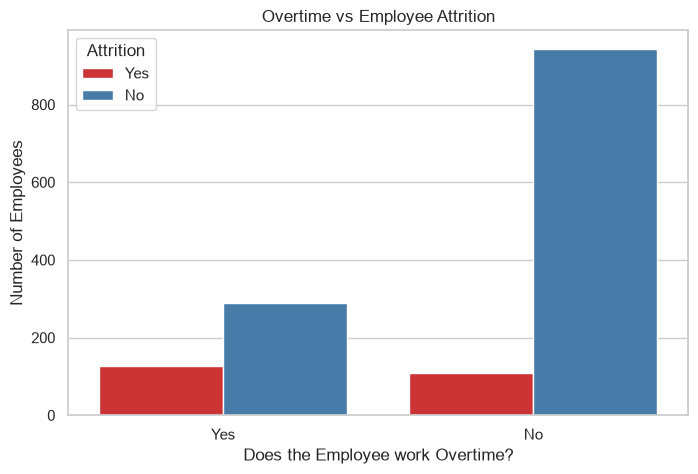

In [8]:
plt.figure(figsize=(8, 5))

# hue='Attrition' pota, Overtime 'Yes' and 'No' kulla evalo per resign pannaanga nu split panni kaatum
sns.countplot(x='OverTime', hue='Attrition', data=df, palette='Set1')

plt.title('Overtime vs Employee Attrition')
plt.xlabel('Does the Employee work Overtime?')
plt.ylabel('Number of Employees')
plt.show()

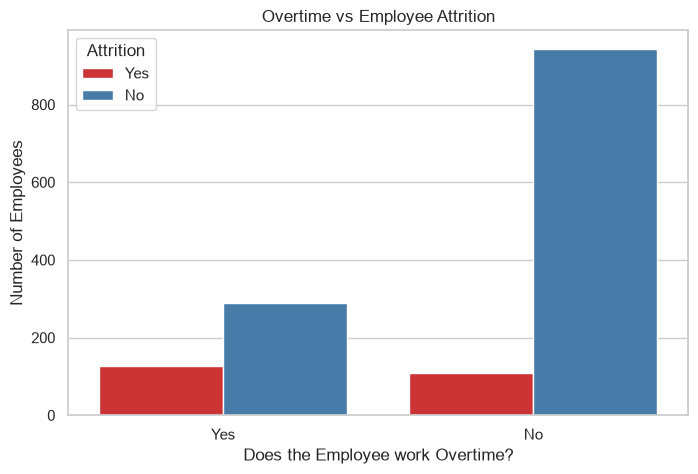

In [9]:
plt.figure(figsize=(8, 5))

# hue='Attrition' pota, Overtime 'Yes' and 'No' kulla evalo per resign pannaanga nu split panni kaatum
sns.countplot(x='OverTime', hue='Attrition', data=df, palette='Set1')

plt.title('Overtime vs Employee Attrition')
plt.xlabel('Does the Employee work Overtime?')
plt.ylabel('Number of Employees')
plt.show()

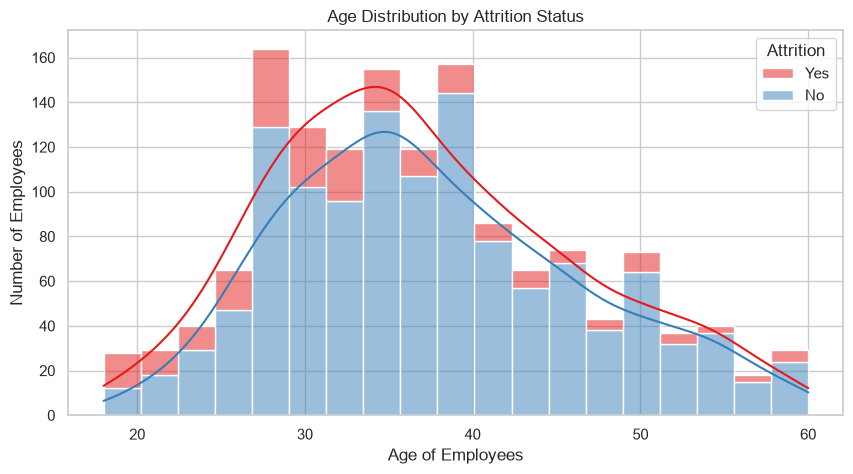

In [10]:
plt.figure(figsize=(10, 5))

# histplot மூலமா வயசோட பரவலை (Distribution) பார்க்க போறோம்.
# kde=True போட்டா ஒரு அழகான ஸ்மூத் கர்வ் (வளைகோடு) லைன் வரும்.
sns.histplot(data=df, x='Age', hue='Attrition', multiple='stack', kde=True, palette='Set1')

plt.title('Age Distribution by Attrition Status')
plt.xlabel('Age of Employees')
plt.ylabel('Number of Employees')
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_18728\1717345511.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='Set2')


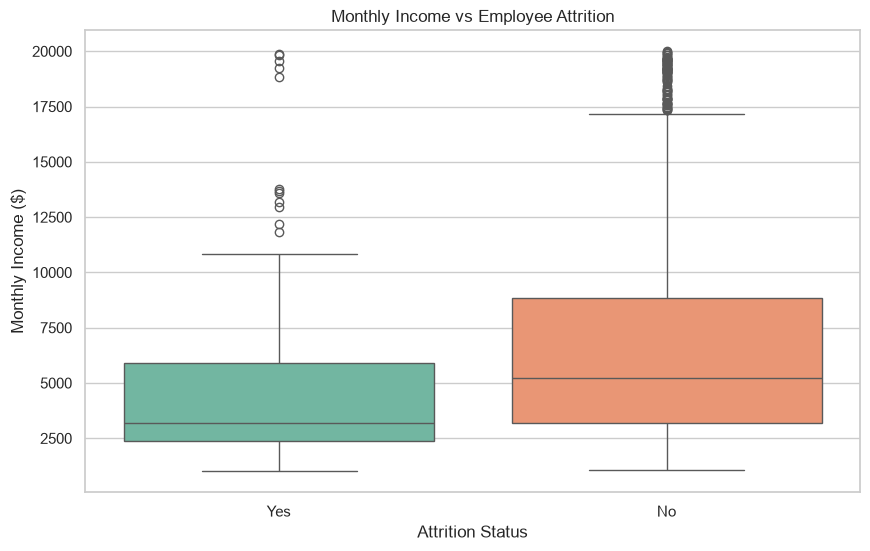

In [11]:
plt.figure(figsize=(10, 6))

# Boxplot use panni Attrition manual variation levels check panrom
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='Set2')

plt.title('Monthly Income vs Employee Attrition')
plt.xlabel('Attrition Status')
plt.ylabel('Monthly Income ($)')
plt.show()

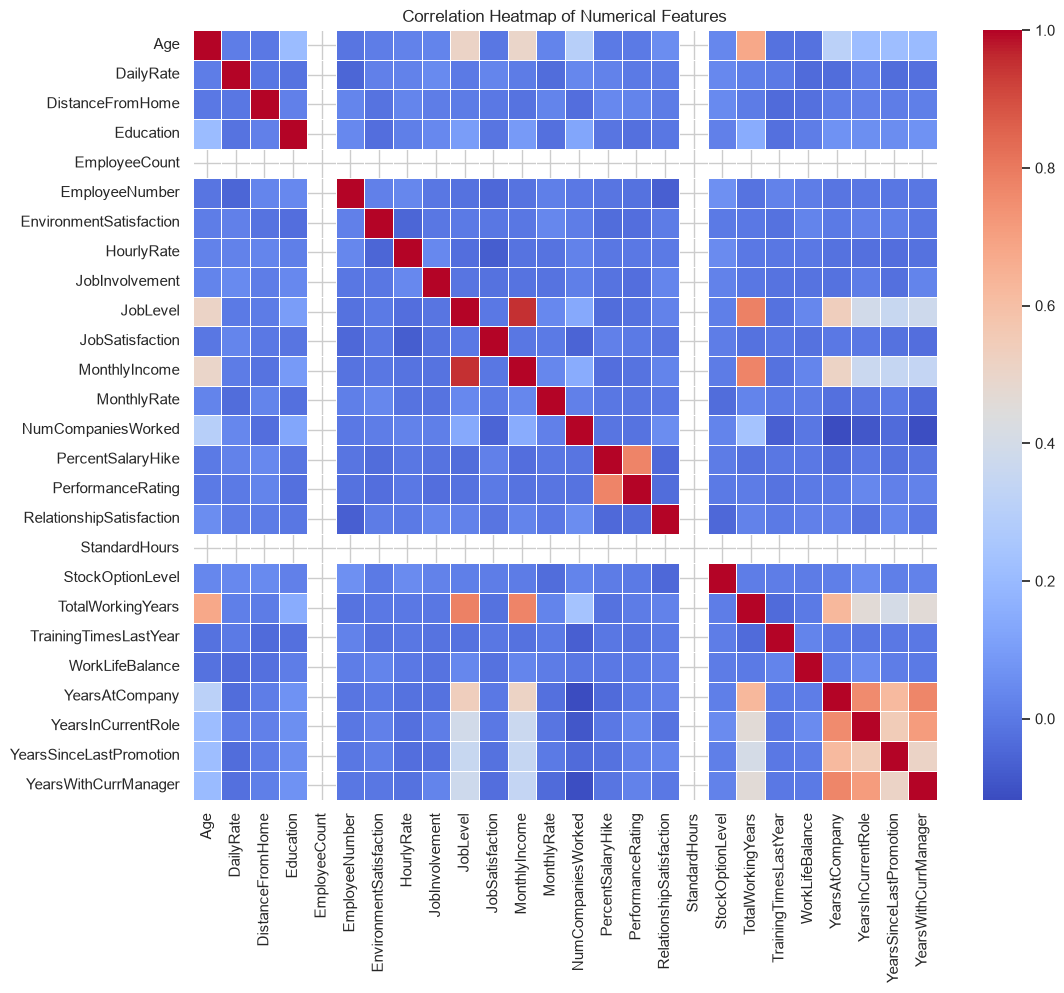

In [12]:
plt.figure(figsize=(12, 10))

# 1. Number columns-ah matum select panrom (Object text columns-ah drop panrom)
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# 2. Correlation matrix calculate panrom
corr_matrix = numeric_df.corr()

# 3. Heatmap visualization plot panrom
# annot=True pota full matrix-layum clear numbers print aagum
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder

# 1. LabelEncoder-ah active panrom
le = LabelEncoder()

# 2. Text columns-ah numbers-aa matha oru chinna list create panrom
categorical_cols = ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 
                    'Gender', 'JobRole', 'MaritalStatus', '11_data_loading_and_eda.ipynb', 'OverTime']

# 3. Text columns-ah loop panni automatic-aa convert panrom
for col in categorical_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])

# 4. Success-aa maariiduchaa nu check panna head() preview pakrom
df[['Attrition', 'OverTime', 'Department']].head()

,Attrition,OverTime,Department
0,1,1,2
1,0,0,1
2,1,1,1
3,0,1,1
4,0,0,1


In [14]:
from sklearn.model_selection import train_test_split

# 1. 'Attrition' காலத்தை மட்டும் நீக்கிட்டு மத்த எல்லாத்தையும் X-ல போடுறோம்
X = df.drop(columns=['Attrition'])

# 2. 'Attrition' காலத்தை மட்டும் y-ல போடுறோம்
y = df['Attrition']

# 3. 80% Training, 20% Testing-க்கு டேட்டாவை பிரிக்கிறோம்
# test_size=0.20-னா 20% பரீட்சைக்குனு அர்த்தம். random_state=42 போட்டா எல்லாருக்கும் ஒரே மாதிரி பிரியும்.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 4. டேட்டா ஒழுங்கா பிரிஞ்சிருக்கான்னு செக் பண்ண Shape பார்க்கிறோம்
print(f"Total training data count (X_train): {X_train.shape[0]}")
print(f"Total testing data count (X_test): {X_test.shape[0]}")

Total training data count (X_train): 1176
Total testing data count (X_test): 294


In [15]:
from sklearn.ensemble import RandomForestClassifier

# 1. நம்பரா மாற்ற முடியாத சில காலம்கள் ஒருவேளை எர்ரர் தராம இருக்க, பாதுகாப்பா டிராப் பண்றோம்
unwanted_cols = ['Over18']
for col in unwanted_cols:
    if col in X_train.columns:
        X_train = X_train.drop(columns=[col])
        X_test = X_test.drop(columns=[col])

# 2. Random Forest AI மாடலை ஆக்டிவேட் பண்றோம்
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 3. Model Fit - 80% ட்ரெய்னிங் டேட்டாவை கொடுத்து AI-க்கு கத்துக் கொடுக்கிறோம்
model.fit(X_train, y_train)

print("AI Model Training Completely Successful! 🎉")

AI Model Training Completely Successful! 🎉


In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. AI-ஐ வச்சு டெஸ்ட் டேட்டாவுக்கு பிரெடிக்ஷன் (கணிப்பு) பண்றோம்
y_pred = model.predict(X_test)

# 2. AI எவ்வளவு மார்க் வாங்குதுன்னு Accuracy கணக்கிடுறோம்
accuracy = accuracy_score(y_test, y_pred)

print("--- 🎯 AI MODEL EVALUATION REPORT ---")
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# 3. Detailed report (Precision, Recall எல்லாமே பார்க்கிறோம்)
print("Classification Report:")
print(classification_report(y_test, y_pred))

--- 🎯 AI MODEL EVALUATION REPORT ---
Model Accuracy: 87.76%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       0.80      0.10      0.18        39

    accuracy                           0.88       294
   macro avg       0.84      0.55      0.56       294
weighted avg       0.87      0.88      0.83       294



In [19]:
import pickle
import os

# Models ஃபோல்டர் இருக்கானு செக் பண்ணி, இல்லைனா அதுவே கிரியேட் பண்ணிடும்
os.makedirs('Models', exist_ok=True)

with open('Models/attrition_rf_model.pkl', 'wb') as f:
    pickle.dump(model, f)
    
with open('Models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Model and Encoder Saved Successfully inside Models folder! 💾")

Model and Encoder Saved Successfully inside Models folder! 💾
